In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow import keras
import joblib

tf.random.set_seed(42)
np.random.seed(42)
df = pd.read_csv("sales_timeseries_features.csv", parse_dates=["date"])
print("Dimensions :", df.shape)
df.head()


Dimensions : (1431, 15)


,date,sales,year,month,day,day_of_week,week_of_year,quarter,is_year_end,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_30,sales_rolling_7,sales_rolling_30
0,2011-01-31,7643,2011,1,31,0,5,1,0,455.0,3983.0,2310.0,808.0,2713.714286,3269.800000
1,2011-02-01,2457,2011,2,1,1,5,1,0,7643.0,1192.0,932.0,314.0,2894.428571,3341.233333
2,2011-02-02,7712,2011,2,2,2,5,1,0,2457.0,5422.0,2054.0,4502.0,3221.571429,3448.233333
3,2011-02-03,366,2011,2,3,3,5,1,0,7712.0,2166.0,2288.0,2809.0,2964.428571,3366.800000
4,2011-02-04,1866,2011,2,4,4,5,1,0,366.0,1208.0,8486.0,3664.0,3058.428571,3306.866667


In [2]:
#Séparation temporelle stricte (train / test)

split_idx = int(len(df) * 0.85)
train_df = df.iloc[:split_idx].reset_index(drop=True)
test_df = df.iloc[split_idx:].reset_index(drop=True)
print(f"Train : {train_df['date'].min().date()} -> {train_df['date'].max().date()} ({len(train_df)} jours)")
print(f"Test  : {test_df['date'].min().date()} -> {test_df['date'].max().date()} ({len(test_df)} jours)")

Train : 2011-01-31 -> 2014-05-30 (1216 jours)
Test  : 2014-05-31 -> 2014-12-31 (215 jours)


In [4]:
#Normalisation des features
feature_cols = [
    "sales", "month", "day_of_week", "quarter", "is_year_end",
    "sales_lag_1", "sales_lag_7", "sales_lag_14", "sales_lag_30",
    "sales_rolling_7", "sales_rolling_30",
]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df[feature_cols])   # fit UNIQUEMENT sur train
test_scaled = scaler.transform(test_df[feature_cols])          # transform seulement sur test

print("Train scaled :", train_scaled.shape)
print("Test scaled  :", test_scaled.shape)

Train scaled : (1216, 11)
Test scaled  : (215, 11)


In [5]:
#3. Construction des séquences
window = 14
def make_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i + window])
        y.append(data[i + window, 0])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(train_scaled, window)
X_test, y_test = make_sequences(test_scaled, window)
print("X_train :", X_train.shape, " (séquences, jours par séquence, features)")
print("y_train :", y_train.shape)
print("X_test  :", X_test.shape)

X_train : (1202, 14, 11)  (séquences, jours par séquence, features)
y_train : (1202,)
X_test  : (201, 14, 11)


In [16]:
#4. Définition et entraînement du modèle LSTM
model = keras.Sequential([
    keras.layers.Input(shape=(window, len(feature_cols))),
    keras.layers.LSTM(32, return_sequences=False),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1),
])

model.compile(optimizer="adam", loss="mse")
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,177 (24.13 KB)

 Trainable params: 6,177 (24.13 KB)

 Non-trainable params: 0 (0.00 B)

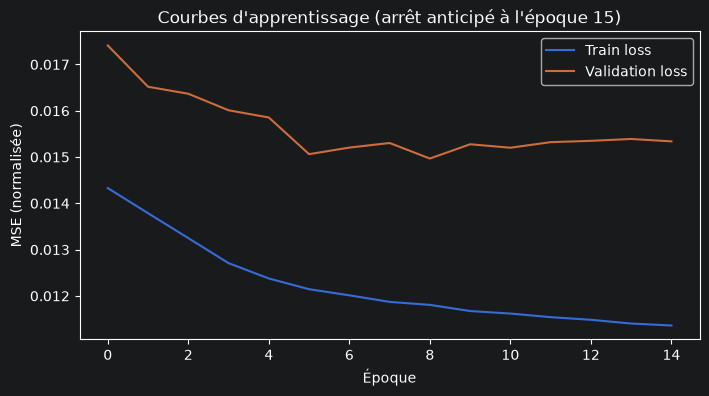

In [13]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)
history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=15,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0,
)

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.legend()
plt.title(f"Courbes d'apprentissage (arrêt anticipé à l'époque {len(history.history['loss'])})")
plt.xlabel("Époque")
plt.ylabel("MSE (normalisée)")
plt.show()

In [14]:
#5. Évaluation sur le jeu de test

y_pred_scaled = model.predict(X_test, verbose=0).flatten()


def inverse_sales(scaled_values, scaler, n_features):
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, 0] = scaled_values
    return scaler.inverse_transform(dummy)[:, 0]


y_test_real = inverse_sales(y_test, scaler, len(feature_cols))
y_pred_real = inverse_sales(y_pred_scaled, scaler, len(feature_cols))

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mask = y_test_real > 500
mape = np.mean(np.abs((y_test_real[mask] - y_pred_real[mask]) / y_test_real[mask])) * 100

print(f"MAE  : {mae:,.2f} $")
print(f"RMSE : {rmse:,.2f} $")
print(f"MAPE : {mape:.2f} % (calculé sur {mask.sum()}/{len(y_test_real)} jours)")
print(f"Moyenne des ventes réelles sur la période de test : {y_test_real.mean():,.2f} $")
print(f"MAE en % de la moyenne : {mae / y_test_real.mean() * 100:.1f}%")


MAE  : 4,943.26 $
RMSE : 6,517.59 $
MAPE : 42.06 % (calculé sur 195/201 jours)
Moyenne des ventes réelles sur la période de test : 14,498.52 $
MAE en % de la moyenne : 34.1%


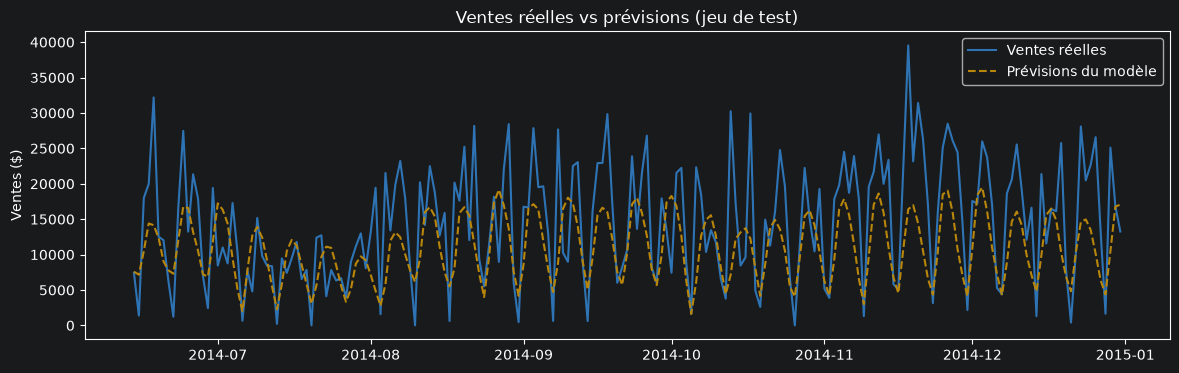

In [10]:
plt.figure(figsize=(14, 4))
plt.plot(test_df["date"].iloc[window:].values, y_test_real, label="Ventes réelles", color="#2E74B5")
plt.plot(test_df["date"].iloc[window:].values, y_pred_real, label="Prévisions du modèle", color="#B8860B", linestyle="--")
plt.legend()
plt.title("Ventes réelles vs prévisions (jeu de test)")
plt.ylabel("Ventes ($)")
plt.show()


In [15]:
#6. Sauvegarde du modèle et du scaler
model.save("models/lstm_sales_forecast.keras")
joblib.dump(scaler, "models/sales_scaler.joblib")
joblib.dump(feature_cols, "models/feature_columns.joblib")

print("Modèle et scaler sauvegardés dans le dossier 'models/'.")

Modèle et scaler sauvegardés dans le dossier 'models/'.
